# Tutorial 4 · Derivatives, Gradients & Contours — Part B

**~40 minutes · after the worksheet**

Move between formulas, contour geometry, directional derivatives, and numerical gradient checks.

Work in pairs. Before each code cell, write down the qualitative result you expect. The notebook is designed to run top-to-bottom in a fresh kernel.


## 1 · Contours and the gradient field


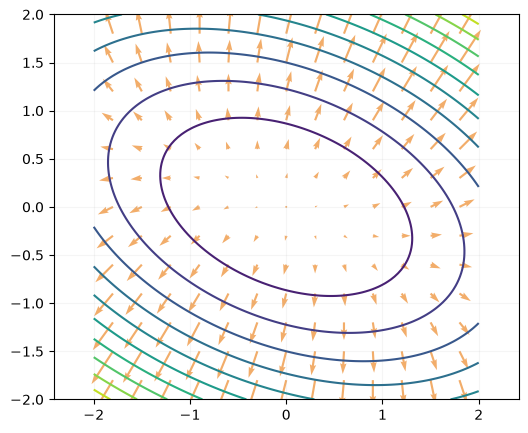

In [1]:
#| fig-alt: 'Contour plot of a quadratic function overlaid with a field of gradient arrows perpendicular to the contours.'
import numpy as np
import matplotlib.pyplot as plt

def f(x, y): return x*x + x*y + 2*y*y
def grad(x, y): return np.array([2*x + y, x + 4*y])

x = np.linspace(-2, 2, 120); X, Y = np.meshgrid(x, x); Z = f(X, Y)
plt.figure(figsize=(6, 5)); plt.contour(X, Y, Z, levels=14)
q = np.linspace(-1.8, 1.8, 13); QX, QY = np.meshgrid(q, q)
G = grad(QX, QY); plt.quiver(QX, QY, G[0], G[1], color="#EB811B", alpha=.65)
plt.axis("equal"); plt.grid(alpha=.12);


## 2 · Directional derivative versus a small step


In [2]:
point = np.array([1., -1.]); direction = np.array([3., 4.]) / 5
exact = grad(*point) @ direction
for h in [1e-1, 1e-3, 1e-5]:
    estimate = (f(*(point + h*direction)) - f(*point)) / h
    print(h, estimate, "error", abs(estimate-exact))
print("exact:", exact)


0.1 -1.5880000000000027 error 0.21199999999999752
0.001 -1.7978800000002515 error 0.0021199999997487673
1e-05 -1.7999787999878334 error 2.1200012166877613e-05
exact: -1.8000000000000003


## 3 · Gradient checking and the U-shaped error curve


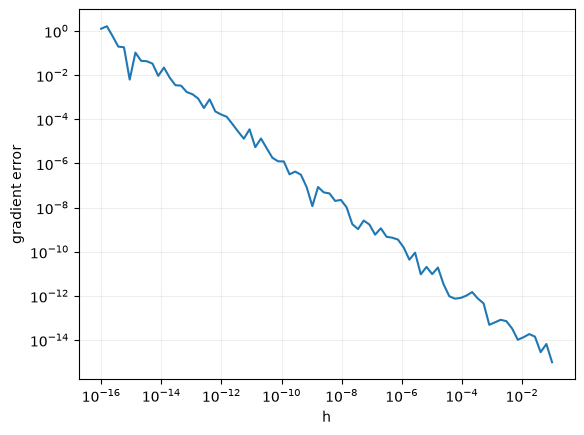

In [3]:
#| fig-alt: 'Log-log curve of central finite-difference gradient error versus step size, showing truncation error at large steps and rounding error at tiny steps.'
hs = np.logspace(-16, -1, 80)
errors = []
for h in hs:
    gx = (f(point[0]+h, point[1]) - f(point[0]-h, point[1]))/(2*h)
    gy = (f(point[0], point[1]+h) - f(point[0], point[1]-h))/(2*h)
    errors.append(np.linalg.norm([gx, gy] - grad(*point)))
plt.loglog(hs, errors); plt.xlabel("h"); plt.ylabel("gradient error"); plt.grid(True, which="both", alpha=.2);


## Closing check

Write three sentences: one numerical result you verified, one geometric/probabilistic interpretation, and one failure mode you would now test in a larger implementation.
